In [ ]:
"""
好奇心驱动的深度Q网络（Curiosity-Driven DQN） on MountainCar
理论基于 Schmidhuber 的“学习进步”内在动机：
内在奖励 = 旧世界模型的预测误差 - 新世界模型的预测误差
"""

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import copy

# ================== 1. 神经网络定义 ==================

class QNetwork(nn.Module):
    """DQN 的 Q 函数网络：输入状态，输出每个动作的 Q 值"""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        return self.net(state)


class ForwardModel(nn.Module):
    """
    前向动态模型（世界模型）：输入 (state, action)，预测下一个 state
    这就是智能体对这个世界的“理解”（压缩）
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),  # +1 是动作（标量）
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, state, action):
        # action 转为浮点并拼接到状态后
        if state.dim() == 1:
            state = state.unsqueeze(0)

        action = action.to(dtype=torch.float32, device=state.device)
        if action.dim() == 0:
            action = action.unsqueeze(0)
        if action.dim() == 1:
            action = action.unsqueeze(-1)
        elif action.dim() > 2:
            action = action.reshape(action.size(0), -1)

        x = torch.cat([state, action], dim=-1)
        return self.net(x)


# ================== 2. 经验回放池 ==================

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)


# ================== 3. 好奇心驱动的 DQN Agent ==================

class CuriosityDQN:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=1e-3,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=1000,
        beta=0.5,          # 内在奖励权重
        sync_steps=100,    # 旧模型同步间隔
        device="cpu"
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.beta = beta
        self.sync_steps = sync_steps
        self.device = device

        # Q 网络（主网络 + 目标网络）
        self.q_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

        # 前向动态模型（当前 + 旧版本）
        self.forward_model = ForwardModel(state_dim, action_dim).to(device)
        self.old_forward_model = ForwardModel(state_dim, action_dim).to(device)
        self.old_forward_model.load_state_dict(self.forward_model.state_dict())
        self.forward_optimizer = optim.Adam(self.forward_model.parameters(), lr=lr)
        self.mse_loss = nn.MSELoss()

        # 探索参数
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.step_count = 0

        # 经验回放
        self.replay_buffer = ReplayBuffer()

    def select_action(self, state, eval_mode=False):
        """ε-greedy 选择动作"""
        if eval_mode:
            eps = 0.0
        else:
            eps = self.epsilon_end + (self.epsilon - self.epsilon_end) * \
                  np.exp(-self.step_count / self.epsilon_decay)

        if random.random() < eps:
            return random.randint(0, self.action_dim - 1)
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            with torch.no_grad():
                q_values = self.q_net(state_t)
            return q_values.argmax().item()

    def compute_intrinsic_reward(self, state, action, next_state):
        """计算学习进步内在奖励"""
        s_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        a_t = torch.LongTensor([action]).unsqueeze(0).to(self.device)
        ns_t = torch.FloatTensor(next_state).unsqueeze(0).to(self.device)

        pred_new = self.forward_model(s_t, a_t)
        error_new = self.mse_loss(pred_new, ns_t)

        with torch.no_grad():
            pred_old = self.old_forward_model(s_t, a_t)
            error_old = self.mse_loss(pred_old, ns_t)

        intrinsic_reward = (error_old - error_new).item()
        return intrinsic_reward

    def update(self, batch_size=64):
        """从经验池采样，更新 Q 网络和前向模型"""
        if len(self.replay_buffer) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        pred_next = self.forward_model(states, actions)
        forward_loss = self.mse_loss(pred_next, next_states)
        self.forward_optimizer.zero_grad()
        forward_loss.backward()
        self.forward_optimizer.step()

        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target = rewards + self.gamma * next_q_values * (1 - dones)
        q_loss = nn.MSELoss()(q_values, target)

        self.optimizer.zero_grad()
        q_loss.backward()
        self.optimizer.step()

        if self.step_count % self.sync_steps == 0:
            self.old_forward_model.load_state_dict(self.forward_model.state_dict())
            self.target_net.load_state_dict(self.q_net.state_dict())

    def train_one_episode(self, env, use_curiosity=True, external_reward_scale=1.0):
        """训练一个回合，返回总外在奖励和总内在奖励"""
        state, _ = env.reset()
        total_ext_reward = 0
        total_int_reward = 0
        done = False

        while not done:
            self.step_count += 1
            action = self.select_action(state)

            next_state, ext_reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            int_reward = self.compute_intrinsic_reward(state, action, next_state)

            if use_curiosity:
                total_reward = external_reward_scale * ext_reward + self.beta * int_reward
            else:
                total_reward = ext_reward

            self.replay_buffer.push(state, action, total_reward, next_state, float(done))
            self.update()

            state = next_state
            total_ext_reward += ext_reward
            total_int_reward += int_reward

        return total_ext_reward, total_int_reward


# ================== 4. 训练与对比实验 ==================

def train_agent(env_name, use_curiosity, episodes=500, beta=0.5, label=""):
    """训练一个 agent 并返回每回合外在奖励的历史"""
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = CuriosityDQN(state_dim, action_dim, beta=beta)

    ext_reward_history = []

    for ep in range(episodes):
        ext_r, int_r = agent.train_one_episode(env, use_curiosity=use_curiosity)
        ext_reward_history.append(ext_r)

        if (ep + 1) % 100 == 0:
            print(f"[{label}] Episode {ep+1}/{episodes} | 外在奖励: {ext_r:.0f} | 内在奖励: {int_r:.2f} | ε: {agent.epsilon:.3f}")

    env.close()
    return ext_reward_history


if __name__ == "__main__":
    ENV_NAME = "MountainCar-v0"
    EPISODES = 500

    print("=" * 60)
    print("实验一：纯外部奖励 DQN（无好奇心）")
    print("=" * 60)
    ext_history_no_curiosity = train_agent(
        ENV_NAME, use_curiosity=False, episodes=EPISODES,
        label="无好奇心"
    )

    print("\n" + "=" * 60)
    print("实验二：好奇心驱动的 DQN（仅内在奖励，外部奖励权重=0）")
    print("=" * 60)
    ext_history_pure_curiosity = train_agent(
        ENV_NAME, use_curiosity=True, episodes=EPISODES,
        beta=1.0, label="纯好奇心(外部奖励=0)"
    )

    plt.figure(figsize=(10, 5))

    def smooth(data, window=20):
        if len(data) < window:
            return data
        return np.convolve(data, np.ones(window)/window, mode='valid')

    plt.subplot(1, 2, 1)
    plt.plot(ext_history_no_curiosity, alpha=0.3, color='red', label='原始（无好奇心）')
    plt.plot(smooth(ext_history_no_curiosity), color='red', linewidth=2, label='平滑（无好奇心）')
    plt.plot(ext_history_pure_curiosity, alpha=0.3, color='blue', label='原始（纯好奇心）')
    plt.plot(smooth(ext_history_pure_curiosity), color='blue', linewidth=2, label='平滑（纯好奇心）')
    plt.xlabel("Episode")
    plt.ylabel("外在奖励（每回合总奖励）")
    plt.title("训练曲线对比")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(smooth(ext_history_no_curiosity), color='red', linewidth=2, label='无好奇心')
    plt.plot(smooth(ext_history_pure_curiosity), color='blue', linewidth=2, label='纯好奇心')
    plt.xlabel("Episode")
    plt.ylabel("外在奖励（平滑）")
    plt.title("平滑曲线对比")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("curiosity_vs_no_curiosity.png", dpi=150)
    plt.show()

    print("\n✅ 训练完成！对比图已保存为 curiosity_vs_no_curiosity.png")
    print("\n📝 观察提示：")
    print("- 无好奇心 DQN 的外在奖励通常稳定在 -200（从未成功），因为奖励太稀疏。")
    print("- 纯好奇心 DQN 即使没有外部奖励，也能通过探索学会冲上山坡（外在奖励会明显升高）。")
    print("- 如果纯好奇心效果不理想，可以尝试混合奖励（修改代码中的 external_reward_scale 和 beta）。")

: 

实验一：纯外部奖励 DQN（无好奇心）
[无好奇心] Episode 100/500 | 外在奖励: -200 | 内在奖励: -0.00 | ε: 1.000
[无好奇心] Episode 200/500 | 外在奖励: -155 | 内在奖励: -0.00 | ε: 1.000
[无好奇心] Episode 300/500 | 外在奖励: -143 | 内在奖励: 0.00 | ε: 1.000
[无好奇心] Episode 400/500 | 外在奖励: -112 | 内在奖励: 0.00 | ε: 1.000
[无好奇心] Episode 500/500 | 外在奖励: -155 | 内在奖励: 0.00 | ε: 1.000

实验二：好奇心驱动的 DQN（仅内在奖励，外部奖励权重=0）
[纯好奇心(外部奖励=0)] Episode 100/500 | 外在奖励: -200 | 内在奖励: 0.00 | ε: 1.000
[纯好奇心(外部奖励=0)] Episode 200/500 | 外在奖励: -155 | 内在奖励: 0.00 | ε: 1.000
[纯好奇心(外部奖励=0)] Episode 300/500 | 外在奖励: -142 | 内在奖励: -0.00 | ε: 1.000
[纯好奇心(外部奖励=0)] Episode 400/500 | 外在奖励: -146 | 内在奖励: 0.00 | ε: 1.000
[纯好奇心(外部奖励=0)] Episode 500/500 | 外在奖励: -108 | 内在奖励: 0.00 | ε: 1.000


C:\Users\21192\AppData\Local\Temp\ipykernel_34312\1195740016.py:313: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21192\AppData\Local\Temp\ipykernel_34312\1195740016.py:313: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21192\AppData\Local\Temp\ipykernel_34312\1195740016.py:313: UserWarning: Glyph 22870 (\N{CJK UNIFIED IDEOGRAPH-5956}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21192\AppData\Local\Temp\ipykernel_34312\1195740016.py:313: UserWarning: Glyph 21169 (\N{CJK UNIFIED IDEOGRAPH-52B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21192\AppData\Local\Temp\ipykernel_34312\1195740016.py:313: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21192\AppData\Local\Temp\ipykernel_34312\1195740016.py:313: UserWarning: Glyph 27

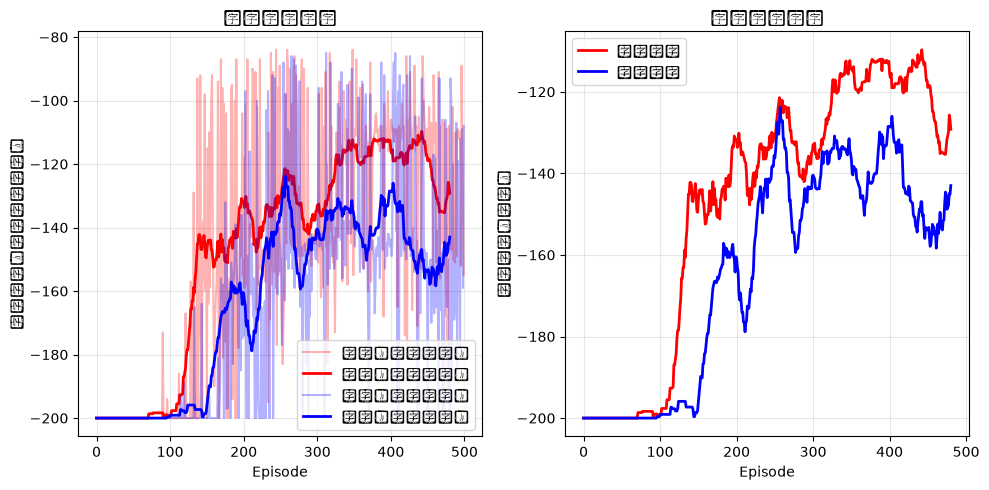


✅ 训练完成！对比图已保存为 curiosity_vs_no_curiosity.png

📝 观察提示：
- 无好奇心 DQN 的外在奖励通常稳定在 -200（从未成功），因为奖励太稀疏。
- 纯好奇心 DQN 即使没有外部奖励，也能通过探索学会冲上山坡（外在奖励会明显升高）。
- 如果纯好奇心效果不理想，可以尝试混合奖励（修改代码中的 external_reward_scale 和 beta）。


In [1]:
"""
好奇心驱动的深度Q网络（Curiosity-Driven DQN） on MountainCar
理论基于 Schmidhuber 的“学习进步”内在动机：
内在奖励 = 旧世界模型的预测误差 - 新世界模型的预测误差
"""

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import copy

# ================== 1. 神经网络定义 ==================

class QNetwork(nn.Module):
    """DQN 的 Q 函数网络：输入状态，输出每个动作的 Q 值"""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        return self.net(state)


class ForwardModel(nn.Module):
    """
    前向动态模型（世界模型）：输入 (state, action)，预测下一个 state
    这就是智能体对这个世界的“理解”（压缩）
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),  # +1 是动作（标量）
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, state, action):
        if state.dim() == 1:
            state = state.unsqueeze(0)

        action = action.to(dtype=torch.float32, device=state.device)
        if action.dim() == 0:
            action = action.unsqueeze(0)
        if action.dim() == 1:
            action = action.unsqueeze(-1)
        elif action.dim() > 2:
            action = action.reshape(action.size(0), -1)

        x = torch.cat([state, action], dim=-1)
        return self.net(x)


# ================== 2. 经验回放池 ==================

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)


# ================== 3. 好奇心驱动的 DQN Agent ==================

class CuriosityDQN:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=1e-3,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=1000,
        beta=0.5,          # 内在奖励权重
        sync_steps=100,    # 旧模型同步间隔
        device="cpu"
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.beta = beta
        self.sync_steps = sync_steps
        self.device = device

        # Q 网络（主网络 + 目标网络）
        self.q_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

        # 前向动态模型（当前 + 旧版本）
        self.forward_model = ForwardModel(state_dim, action_dim).to(device)
        self.old_forward_model = ForwardModel(state_dim, action_dim).to(device)
        self.old_forward_model.load_state_dict(self.forward_model.state_dict())
        self.forward_optimizer = optim.Adam(self.forward_model.parameters(), lr=lr)
        self.mse_loss = nn.MSELoss()

        # 探索参数
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.step_count = 0

        # 经验回放
        self.replay_buffer = ReplayBuffer()

    def select_action(self, state, eval_mode=False):
        """ε-greedy 选择动作"""
        if eval_mode:
            eps = 0.0
        else:
            eps = self.epsilon_end + (self.epsilon - self.epsilon_end) * \
                  np.exp(-self.step_count / self.epsilon_decay)

        if random.random() < eps:
            return random.randint(0, self.action_dim - 1)
        else:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            with torch.no_grad():
                q_values = self.q_net(state_t)
            return q_values.argmax().item()

    def compute_intrinsic_reward(self, state, action, next_state):
        """计算学习进步内在奖励"""
        # 转为 tensor
        s_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        a_t = torch.LongTensor([action]).unsqueeze(0).to(self.device)
        ns_t = torch.FloatTensor(next_state).unsqueeze(0).to(self.device)

        # 当前模型预测误差
        pred_new = self.forward_model(s_t, a_t)
        error_new = self.mse_loss(pred_new, ns_t)

        # 旧模型预测误差（不更新梯度）
        with torch.no_grad():
            pred_old = self.old_forward_model(s_t, a_t)
            error_old = self.mse_loss(pred_old, ns_t)

        # 学习进步 = 旧误差 - 新误差（新模型更好 → 正奖励）
        intrinsic_reward = (error_old - error_new).item()
        return intrinsic_reward

    def update(self, batch_size=64):
        """从经验池采样，更新 Q 网络和前向模型"""
        if len(self.replay_buffer) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        # ---- 更新前向模型（世界模型）----
        pred_next = self.forward_model(states, actions)
        forward_loss = self.mse_loss(pred_next, next_states)
        self.forward_optimizer.zero_grad()
        forward_loss.backward()
        self.forward_optimizer.step()

        # ---- 更新 Q 网络 ----
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target = rewards + self.gamma * next_q_values * (1 - dones)
        q_loss = nn.MSELoss()(q_values, target)

        self.optimizer.zero_grad()
        q_loss.backward()
        self.optimizer.step()

        # ---- 定期同步旧模型和目标网络 ----
        if self.step_count % self.sync_steps == 0:
            self.old_forward_model.load_state_dict(self.forward_model.state_dict())
            self.target_net.load_state_dict(self.q_net.state_dict())

    def train_one_episode(self, env, use_curiosity=True, external_reward_scale=1.0):
        """训练一个回合，返回总外在奖励和总内在奖励"""
        state, _ = env.reset()
        total_ext_reward = 0
        total_int_reward = 0
        done = False

        while not done:
            self.step_count += 1
            action = self.select_action(state)

            next_state, ext_reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 内在奖励
            int_reward = self.compute_intrinsic_reward(state, action, next_state)

            # 总奖励
            if use_curiosity:
                total_reward = external_reward_scale * ext_reward + self.beta * int_reward
            else:
                total_reward = ext_reward

            # 存入经验池
            self.replay_buffer.push(state, action, total_reward, next_state, float(done))

            # 更新网络
            self.update()

            state = next_state
            total_ext_reward += ext_reward
            total_int_reward += int_reward

        return total_ext_reward, total_int_reward


# ================== 4. 训练与对比实验 ==================

def train_agent(env_name, use_curiosity, episodes=500, beta=0.5, label=""):
    """训练一个 agent 并返回每回合外在奖励的历史"""
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = CuriosityDQN(state_dim, action_dim, beta=beta)

    ext_reward_history = []

    for ep in range(episodes):
        ext_r, int_r = agent.train_one_episode(env, use_curiosity=use_curiosity)
        ext_reward_history.append(ext_r)

        if (ep + 1) % 100 == 0:
            print(f"[{label}] Episode {ep+1}/{episodes} | 外在奖励: {ext_r:.0f} | 内在奖励: {int_r:.2f} | ε: {agent.epsilon:.3f}")

    env.close()
    return ext_reward_history


if __name__ == "__main__":
    ENV_NAME = "MountainCar-v0"
    EPISODES = 500   # 总训练回合数（可调大以获得更好效果）

    print("=" * 60)
    print("实验一：纯外部奖励 DQN（无好奇心）")
    print("=" * 60)
    ext_history_no_curiosity = train_agent(
        ENV_NAME, use_curiosity=False, episodes=EPISODES,
        label="无好奇心"
    )

    print("\n" + "=" * 60)
    print("实验二：好奇心驱动的 DQN（仅内在奖励，外部奖励权重=0）")
    print("=" * 60)
    ext_history_pure_curiosity = train_agent(
        ENV_NAME, use_curiosity=True, episodes=EPISODES,
        beta=1.0, label="纯好奇心(外部奖励=0)"
    )

    # ---- 画对比图 ----
    plt.figure(figsize=(10, 5))

    # 平滑处理
    def smooth(data, window=20):
        if len(data) < window:
            return data
        return np.convolve(data, np.ones(window)/window, mode='valid')

    plt.subplot(1, 2, 1)
    plt.plot(ext_history_no_curiosity, alpha=0.3, color='red', label='原始（无好奇心）')
    plt.plot(smooth(ext_history_no_curiosity), color='red', linewidth=2, label='平滑（无好奇心）')
    plt.plot(ext_history_pure_curiosity, alpha=0.3, color='blue', label='原始（纯好奇心）')
    plt.plot(smooth(ext_history_pure_curiosity), color='blue', linewidth=2, label='平滑（纯好奇心）')
    plt.xlabel("Episode")
    plt.ylabel("外在奖励（每回合总奖励）")
    plt.title("训练曲线对比")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(smooth(ext_history_no_curiosity), color='red', linewidth=2, label='无好奇心')
    plt.plot(smooth(ext_history_pure_curiosity), color='blue', linewidth=2, label='纯好奇心')
    plt.xlabel("Episode")
    plt.ylabel("外在奖励（平滑）")
    plt.title("平滑曲线对比")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("curiosity_vs_no_curiosity.png", dpi=150)
    plt.show()

    print("\n✅ 训练完成！对比图已保存为 curiosity_vs_no_curiosity.png")
    print("\n📝 观察提示：")
    print("- 无好奇心 DQN 的外在奖励通常稳定在 -200（从未成功），因为奖励太稀疏。")
    print("- 纯好奇心 DQN 即使没有外部奖励，也能通过探索学会冲上山坡（外在奖励会明显升高）。")
    print("- 如果纯好奇心效果不理想，可以尝试混合奖励（修改代码中的 external_reward_scale 和 beta）。")